In [1]:
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from transformers import AutoTokenizer, AutoModelForSequenceClassification

print("Imports successful! ✅")

Imports successful! ✅


In [2]:
DATA_DIR = Path("../data/raw")

TEST_PATH = DATA_DIR / "test.csv"

test_df = pd.read_csv(
    TEST_PATH,
    nrows=5000
)

test_df = test_df.rename(columns={
    "class_index": "label",
    "review_title": "title",
    "review_text": "text"
})

test_df["label"] = test_df["label"].map({
    1: 0,
    2: 1
})

test_df["text"] = (
    test_df["title"].fillna("") + " " +
    test_df["text"].fillna("")
).str.strip()

test_df = test_df[["text", "label"]]

print(test_df.shape)
print(test_df.head())

(5000, 2)
                                                text  label
0  Great CD My lovely Pat has one of the GREAT vo...      1
1  One of the best game music soundtracks - for a...      1
2  Batteries died within a year ... I bought this...      0
3  works fine, but Maha Energy is better Check ou...      1
4  Great for the non-audiophile Reviewed quite a ...      1


In [3]:
MODEL_PATH = "../models/distilbert"

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_PATH
)

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_PATH
)

model.eval()

print("Trained DistilBERT loaded! ✅")

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Trained DistilBERT loaded! ✅


In [4]:
predictions = []
probabilities = []

batch_size = 16

for i in range(0, len(test_df), batch_size):

    batch = test_df["text"].iloc[i:i + batch_size].tolist()

    inputs = tokenizer(
        batch,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=128
    )

    with torch.no_grad():

        outputs = model(**inputs)

    probs = torch.softmax(
        outputs.logits,
        dim=-1
    )

    preds = torch.argmax(
        probs,
        dim=-1
    )

    predictions.extend(
        preds.cpu().numpy()
    )

    probabilities.extend(
        probs.cpu().numpy()
    )

print("Predictions generated! ✅")

Predictions generated! ✅


In [5]:
analysis_df = test_df.copy()

analysis_df["prediction"] = predictions

probabilities = np.array(probabilities)

analysis_df["confidence"] = probabilities.max(axis=1)

analysis_df["correct"] = (
    analysis_df["label"] ==
    analysis_df["prediction"]
)

analysis_df["review_length"] = (
    analysis_df["text"]
    .str.split()
    .str.len()
)

print(analysis_df.head())

                                                text  label  prediction  \
0  Great CD My lovely Pat has one of the GREAT vo...      1           1   
1  One of the best game music soundtracks - for a...      1           1   
2  Batteries died within a year ... I bought this...      0           0   
3  works fine, but Maha Energy is better Check ou...      1           1   
4  Great for the non-audiophile Reviewed quite a ...      1           1   

   confidence  correct  review_length  
0    0.997133     True            106  
1    0.997228     True            148  
2    0.993272     True             60  
3    0.986996     True             37  
4    0.995053     True             69  


In [6]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

accuracy = accuracy_score(
    analysis_df["label"],
    analysis_df["prediction"]
)

precision = precision_score(
    analysis_df["label"],
    analysis_df["prediction"]
)

recall = recall_score(
    analysis_df["label"],
    analysis_df["prediction"]
)

f1 = f1_score(
    analysis_df["label"],
    analysis_df["prediction"]
)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

Accuracy : 0.9318
Precision: 0.9361
Recall   : 0.9306
F1 Score : 0.9333


In [7]:
errors = analysis_df[
    analysis_df["correct"] == False
].copy()

print("Total errors:", len(errors))
print("Error rate:", len(errors) / len(analysis_df))


Total errors: 341
Error rate: 0.0682


In [8]:
errors.sort_values(
    "confidence",
    ascending=False
)[
    ["text", "label", "prediction", "confidence"]
].head(20)

,text,label,prediction,confidence
4300,A Great Book This is a GREAT book! I was thril...,0,1,0.997346
923,You must read this book! This was my first enc...,0,1,0.997132
1554,AWESOME!!! I fell in love with clay the first ...,0,1,0.996987
4471,ZOOM IN OR OUT Alvin Lee Zoom album is a non p...,0,1,0.996822
253,Worst Night World book This is the worst book ...,1,0,0.996706
2991,Great movie! I really liked this movie! They p...,0,1,0.996686
552,Reaching for the Light I have really enjoyed t...,0,1,0.996641
3414,thank you This one gift I could give my grown ...,0,1,0.996608
1920,God's and Kings: Chronicles of the Kings #1 Th...,0,1,0.996505
4690,Retraction! Company fixed CD Works Great now! ...,0,1,0.996119


In [9]:
false_positives = analysis_df[
    (analysis_df["label"] == 0) &
    (analysis_df["prediction"] == 1)
]

print("False positives:", len(false_positives))

false_positives[
    ["text", "confidence"]
].sort_values(
    "confidence",
    ascending=False
).head(10)


False positives: 163


,text,confidence
4300,A Great Book This is a GREAT book! I was thril...,0.997346
923,You must read this book! This was my first enc...,0.997132
1554,AWESOME!!! I fell in love with clay the first ...,0.996987
4471,ZOOM IN OR OUT Alvin Lee Zoom album is a non p...,0.996822
2991,Great movie! I really liked this movie! They p...,0.996686
552,Reaching for the Light I have really enjoyed t...,0.996641
3414,thank you This one gift I could give my grown ...,0.996608
1920,God's and Kings: Chronicles of the Kings #1 Th...,0.996505
4690,Retraction! Company fixed CD Works Great now! ...,0.996119
864,Great movie butt o grainy on blueray I like al...,0.996035


In [10]:
false_negatives = analysis_df[
    (analysis_df["label"] == 1) &
    (analysis_df["prediction"] == 0)
]

print("False negatives:", len(false_negatives))

false_negatives[
    ["text", "confidence"]
].sort_values(
    "confidence",
    ascending=False
).head(10)

False negatives: 178


,text,confidence
253,Worst Night World book This is the worst book ...,0.996706
2568,typos galore! I do not intend to review conten...,0.995984
3066,BD-live features mostly worthless I explored t...,0.995569
3961,Too Complex I am a long time US Robotics Pilot...,0.995359
3775,Looking Backward I have a bad habit of diving ...,0.995338
2156,"Too much is not enough My boys, ages 5 and 7, ...",0.995098
550,"Basketball, not at its best Ok, as yall might ...",0.994405
4292,"Wonderful book, very tasteless introduction! T...",0.994185
2383,"One glaring omission, one glaringly bad inclus...",0.994117
2001,Purrfect These shoes are a little high price w...,0.994006


In [11]:
analysis_df["length_category"] = pd.cut(
    analysis_df["review_length"],
    bins=[0, 10, 30, 60, 100, np.inf],
    labels=[
        "Very Short",
        "Short",
        "Medium",
        "Long",
        "Very Long"
    ]
)

length_performance = (
    analysis_df
    .groupby("length_category", observed=True)
    .apply(
        lambda x: pd.Series({
            "samples": len(x),
            "accuracy": accuracy_score(
                x["label"],
                x["prediction"]
            )
        }),
        include_groups=False
    )
)

length_performance

,samples,accuracy
length_category,,
Short,605.0,0.933884
Medium,1421.0,0.940183
Long,1448.0,0.937155
Very Long,1526.0,0.918087


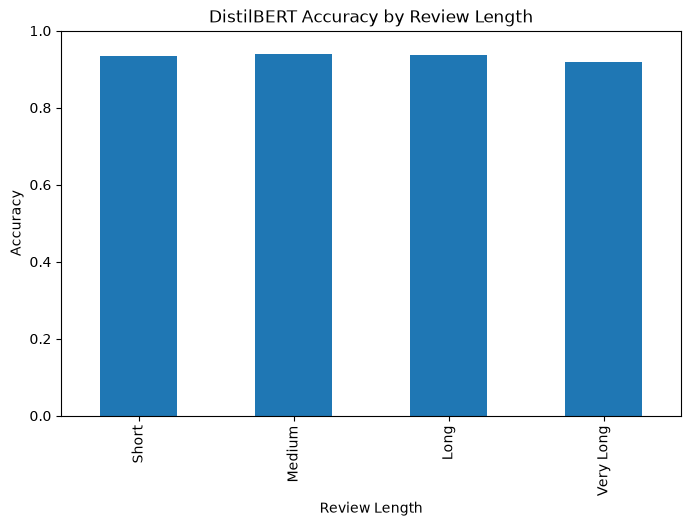

In [12]:
length_performance["accuracy"].plot(
    kind="bar",
    figsize=(8, 5),
    title="DistilBERT Accuracy by Review Length"
)

plt.ylabel("Accuracy")
plt.xlabel("Review Length")
plt.ylim(0, 1)
plt.show()

In [13]:
high_confidence_errors = errors[
    errors["confidence"] >= 0.90
].sort_values(
    "confidence",
    ascending=False
)

print(
    "High-confidence errors:",
    len(high_confidence_errors)
)

high_confidence_errors[
    ["text", "label", "prediction", "confidence"]
].head(20)

High-confidence errors: 225


,text,label,prediction,confidence
4300,A Great Book This is a GREAT book! I was thril...,0,1,0.997346
923,You must read this book! This was my first enc...,0,1,0.997132
1554,AWESOME!!! I fell in love with clay the first ...,0,1,0.996987
4471,ZOOM IN OR OUT Alvin Lee Zoom album is a non p...,0,1,0.996822
253,Worst Night World book This is the worst book ...,1,0,0.996706
2991,Great movie! I really liked this movie! They p...,0,1,0.996686
552,Reaching for the Light I have really enjoyed t...,0,1,0.996641
3414,thank you This one gift I could give my grown ...,0,1,0.996608
1920,God's and Kings: Chronicles of the Kings #1 Th...,0,1,0.996505
4690,Retraction! Company fixed CD Works Great now! ...,0,1,0.996119


In [14]:
negation_words = [
    "not",
    "never",
    "neither",
    "hardly",
    "nothing"
]

negation_pattern = (
    r"\b(" +
    "|".join(negation_words) +
    r")\b"
)

analysis_df["contains_negation"] = (
    analysis_df["text"]
    .str.lower()
    .str.contains(
        negation_pattern,
        regex=True,
        na=False
    )
)

negation_performance = (
    analysis_df
    .groupby("contains_negation")
    .apply(
        lambda x: pd.Series({
            "samples": len(x),
            "accuracy": accuracy_score(
                x["label"],
                x["prediction"]
            )
        }),
        include_groups=False
    )
)

negation_performance

C:\Users\DELL\AppData\Local\Temp\ipykernel_34400\3981002194.py:18: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  .str.contains(


,samples,accuracy
contains_negation,,
False,2593.0,0.938681
True,2407.0,0.924387


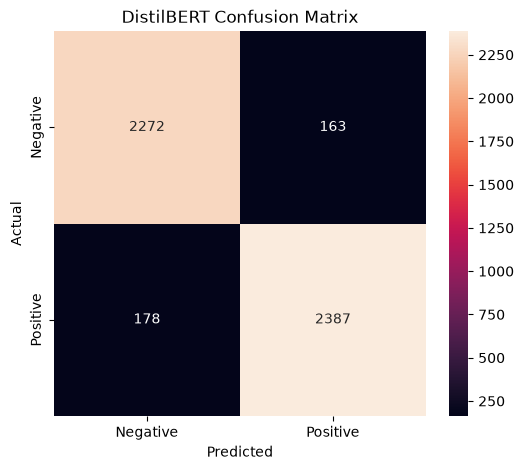

In [15]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    analysis_df["label"],
    analysis_df["prediction"]
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("DistilBERT Confusion Matrix")

plt.show()

In [16]:
errors[
    [
        "text",
        "label",
        "prediction",
        "confidence",
        "review_length"
    ]
].to_csv(
    "../data/error_analysis.csv",
    index=False
)

print("Error analysis saved! ✅")

Error analysis saved! ✅


In [18]:
high_confidence_errors[
    [
        "text",
        "label",
        "prediction",
        "confidence"
    ]
].head(20).to_string(index=False)

'                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                  text  label  prediction  confidence\nA Great Book This is a GREAT book! I was thrilled to find it at my library, because everyone told me that I should read it. This

In [20]:
import shap

print("SHAP version:", shap.__version__)

SHAP version: 0.52.0


In [21]:
import torch
import numpy as np

device = torch.device("cpu")

model.to(device)
model.eval()

def predict_proba(texts):
    inputs = tokenizer(
        list(texts),
        padding=True,
        truncation=True,
        max_length=128,
        return_tensors="pt"
    )

    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)

    probabilities = torch.softmax(outputs.logits, dim=-1)

    return probabilities.cpu().numpy()

In [22]:
test_review = [
    "The battery life is amazing but the camera quality is disappointing."
]

predict_proba(test_review)

array([[0.9860086 , 0.01399137]], dtype=float32)

In [23]:
explainer = shap.Explainer(
    predict_proba,
    shap.maskers.Text(tokenizer)
)

print("SHAP explainer ready!")

SHAP explainer ready!


In [24]:
shap_values = explainer(
    ["The battery life is amazing but the camera quality is disappointing."]
)

shap.plots.text(shap_values[0])

PartitionExplainer explainer: 2it [00:11, 11.27s/it]               


In [25]:
import os
MODEL_DIR = "../models/distilbert"
os.makedirs(MODEL_DIR, exist_ok=True)
model.save_pretrained(MODEL_DIR)
tokenizer.save_pretrained(MODEL_DIR)
print("Model and tokenizer saved!")
print("Location:", MODEL_DIR)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model and tokenizer saved!
Location: ../models/distilbert


In [26]:
import os

print(os.listdir(MODEL_DIR))

['checkpoint-2500', 'config.json', 'model.safetensors', 'tokenizer.json', 'tokenizer_config.json', 'training_args.bin']


In [27]:
import json

results_summary = {
    "tfidf_logistic_regression": {
        "accuracy": 0.9081,
        "precision": 0.9058,
        "recall": 0.9159,
        "f1": 0.9108
    },
    "distilbert": {
        "accuracy": 0.9318,
        "precision": 0.9361,
        "recall": 0.9306,
        "f1": 0.9333
    }
}

with open("../models/results.json", "w") as f:
    json.dump(results_summary, f, indent=4)

print("Results saved!")

Results saved!


In [28]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

test_tokenizer = AutoTokenizer.from_pretrained(MODEL_DIR)
test_model = AutoModelForSequenceClassification.from_pretrained(MODEL_DIR)

print("Model reload successful! ✅")

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Model reload successful! ✅
